In [2]:
import numpy as np
import pandas as pd
from bitalg.tests.test2 import Test
import matplotlib.pyplot as plt
from bitalg.visualizer.main import Visualizer
from functools import cmp_to_key


In [3]:
def det(a, b, c):
    """
    Obliczanie wyznacznika macierzy 3x3 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return a[0]*b[1]+b[0]*c[1] +c[0]*a[1] - b[1]*c[0]-c[1]*a[0]-a[1]*b[0]

In [4]:
def generate_uniform_points(left=-100, right=100, n=100):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym
    obszarze od left do right (jednakowo na osi y)
    o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
             np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    result = [None for _ in range(n)]
    for i in range(n):
        result[i] = (np.random.uniform(left, right), np.random.uniform(left, right))
    return result

In [5]:
def display_convex_hull(v,points,hull):
    v.clear()
    v.add_point(points)
    v.add_point(hull,color="red")
    v.add_line_segment([(hull[i], hull[i+1]) for i in range(len(hull)-1)],color="red")
    v.add_line_segment([hull[-1], hull[0]],color="red")
    v.show()

In [6]:
def mat_det_2x2(a, b, c):
    """
    Obliczanie wyznacznika macierzy 2x2 bez użycia funkcji bibliotecznych
    :param a: krotka współrzędnych (x, y) pierwszego punktu tworzącego naszą prostą
    :param b: krotka współrzędnych (x, y) drugiego punktu tworzącego naszą prostą
    :param c: krotka współrzędnych (x, y) punktu, którego położenie względem prostej chcemy znaleźć
    :return: wartość wyznacznika macierzy
    """
    return (a[0]-c[0])*(b[1]-c[1]) - (b[0]-c[0]) * (a[1]-c[1])

In [7]:
EPS = 10**(-24)
def orient(a,b,c):
    r = mat_det_2x2(a,b,c)
    if abs(r) < EPS:
        return 0
    elif r >0: return 1 
    else: return -1

In [8]:
def find_extreme_x_points(Q):
    min_x_point = min(Q, key=lambda p: (p[0], p[1]))
    max_x_point = max(Q, key=lambda p: (p[0], -p[1]))
    return min_x_point, max_x_point

In [9]:
#wysokość jest proporcjonalna do pola równologłoboku
def P(p1, p2 ,p):
    return det(p1,p2,p)

In [10]:
def divide(Q, p1,p2):
    on_left = []
    on_right = []
    for point in Q:
        if point == p1 or point == p2: continue
        if orient(p1,p2,point) ==1:
            on_left.append(point)
        elif orient(p1, p2, point) == -1:
            on_right.append(point)
    return on_left, on_right

In [11]:
def farthest_point(S, p1,p2):
    max_P = -1
    res = -1
    for p in S:
        if p1 == p or p2== p: continue
        if P(p1,p2, p) > max_P:
            res = p
            max_P = P(p1,p2,p)
    return res

In [12]:

def compare(p0,p1,p2):
    r = orient(p0,p1,p2)
    if r==-1:
            return 1
    elif r==1: return -1

In [13]:
def min_y(Q):
    n = len(Q)
    mini = Q[0]
    for i in range(n):
        if Q[i][1] < mini[1] or (Q[i][1] == mini[1] and Q[i][0] < mini[0]):
            mini=Q[i]
    return mini

In [14]:
def generate_circle_points(O, R, n=100):
    """
    Funkcja generuje jednostajnie n punktów na okręgu o środku O i promieniu R
    :param O: krotka współrzędnych x, y określająca środek okręgu
    :param R: promień okręgu
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
    """
    result = [None for _ in range(n)]
    for i in range(n):
        t = np.random.uniform(0, 2 *np.pi)
        result[i] = (R*np.cos(t)+O[0], R*np.sin(t)+O[1])
    return result
 

In [15]:
def generate_uniform_points(left=-100, right=100, n=100):
    """
    Funkcja generuje równomiernie n punktów na kwadwratowym
    obszarze od left do right (jednakowo na osi y)
    o współrzędnych rzeczywistych
    :param left: lewy kraniec przedziału
    :param right: prawy kraniec przedziału
    :param n: ilość generowanych punktów
    :return: tablica punktów w postaci krotek współrzędnych
             np. [(x1, y1), (x2, y2), ... (xn, yn)]
    """
    result = [None for _ in range(n)]
    for i in range(n):
        result[i] = (np.random.uniform(left, right), np.random.uniform(left, right))
    return result


In [16]:

def quick_hull(points):
    if len(points) <=2:
        return points
    p_min, p_max = find_extreme_x_points(points)
    CH = [p_min, p_max]
    def find_hull(S, A,B):
        nonlocal points, CH
        if not S:
            return
        C = farthest_point(S,A,B)
        if C == -1: return
        CH.append(C)
        left_to_ac, _ = divide(S,A,C)
        left_to_cb, _ = divide(S,C,B)
        find_hull(left_to_ac,A,C)
        find_hull(left_to_cb,C,B)
    on_left, on_right = divide(points, p_min, p_max)
    find_hull(on_left, p_min, p_max) 
    find_hull(on_right, p_max, p_min)
    p0 = min_y(CH)
    CH.remove(p0)
    CH.sort(key=cmp_to_key(lambda a, b: compare(p0, a, b)))
    CH.append(p0)
    return CH
    

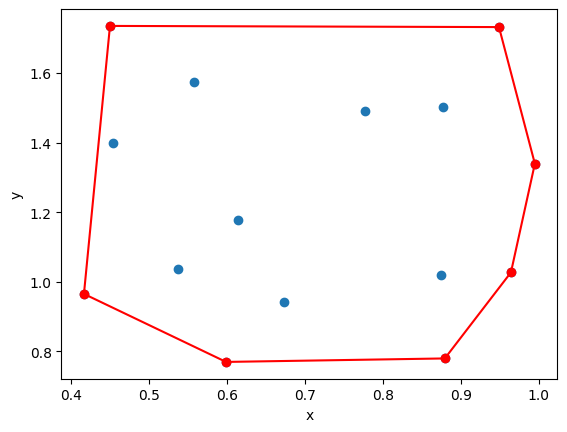

In [17]:
display_convex_hull(Visualizer(), [(np.float64(0.4169057852068113), np.float64(0.96504493874204)),
 (np.float64(0.5991454383700677), np.float64(0.7696318723103349)),
 (np.float64(0.8797223301214179), np.float64(0.7796530552042685)),
 (np.float64(0.9645269211973886), np.float64(1.0268422332546303)),
 (np.float64(0.9952009222248674), np.float64(1.3391691001155606)),
 (np.float64(0.8779179771198014), np.float64(1.5028484207164758)),
 (np.float64(0.5585474958336987), np.float64(1.572996700974011)),
 (np.float64(0.4547971982407557), np.float64(1.399296197479162)),
 (np.float64(0.614482438883807), np.float64(1.178830173812623)),
 (np.float64(0.5368952598143019), np.float64(1.035193218999575)),
 (np.float64(0.6740260879371482), np.float64(0.9416621786561948)),
 (np.float64(0.8743092711165685), np.float64(1.0201614446586746)),
 (np.float64(0.7768742090292831), np.float64(1.4911570406735533)),
 (np.float64(0.9491899206836492), np.float64(1.7316654301279593)),
 (np.float64(0.45028631573671474), np.float64(1.7350058244259372))], quick_hull([(np.float64(0.4169057852068113), np.float64(0.96504493874204)),
 (np.float64(0.5991454383700677), np.float64(0.7696318723103349)),
 (np.float64(0.8797223301214179), np.float64(0.7796530552042685)),
 (np.float64(0.9645269211973886), np.float64(1.0268422332546303)),
 (np.float64(0.9952009222248674), np.float64(1.3391691001155606)),
 (np.float64(0.8779179771198014), np.float64(1.5028484207164758)),
 (np.float64(0.5585474958336987), np.float64(1.572996700974011)),
 (np.float64(0.4547971982407557), np.float64(1.399296197479162)),
 (np.float64(0.614482438883807), np.float64(1.178830173812623)),
 (np.float64(0.5368952598143019), np.float64(1.035193218999575)),
 (np.float64(0.6740260879371482), np.float64(0.9416621786561948)),
 (np.float64(0.8743092711165685), np.float64(1.0201614446586746)),
 (np.float64(0.7768742090292831), np.float64(1.4911570406735533)),
 (np.float64(0.9491899206836492), np.float64(1.7316654301279593)),
 (np.float64(0.45028631573671474), np.float64(1.7350058244259372))]))

In [394]:
Test().runtest(1, quick_hull)

Lab 2, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
	Test 11: Passed
Result: 11/11
Time: 2.301s


In [347]:

def quick_hull_vis(points):
    vis = Visualizer()
    vis.add_point(points)
    p_min, p_max = find_extreme_x_points(points)
    CH = [p_min, p_max]
    def find_hull(S, A,B, last_line):
        nonlocal points, CH, vis
        if not S:
            return
        
        C = farthest_point(S,A,B)
        CH.append(C)
        vis.add_point(C, color="red")
        ac_line = vis.add_line_segment([A, C], color="red")
        cb_line = vis.add_line_segment([C, B], color="red")
        
        left_to_ac, _ = divide(S,A,C)
        left_to_cb, _ = divide(S,C,B)
        if last_line is not None:
            vis.remove_figure(last_line)
            
        find_hull(left_to_ac,A,C, ac_line)
        find_hull(left_to_cb,C,B, cb_line)
    vis.add_point(CH, color="red")
    on_left, on_right = divide(points, p_min, p_max)
    line = vis.add_line_segment([p_min, p_max], color="red")
    find_hull(on_left, p_min, p_max, None) 
    find_hull(on_right, p_max, p_min, line)
    return vis

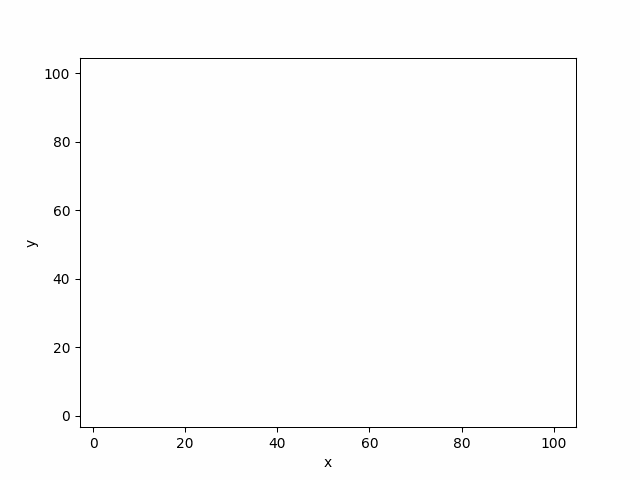

In [348]:
test = generate_uniform_points(0,100,100)
vis = quick_hull_vis(test)
vis.show_gif(interval=500)